In [ ]:
import requests
import pandas as pd

print("Libraries imported successfully!")

Libraries imported successfully!


Project Overview:-

This project examines Machine Learning repositories aggregated by using GitHub.

Some context on the data itself: it was collected through Github API, cleaned and prepared with Python + Pandas, analyzed with SQL and visualized in order to find any patterns or insights that could be useful.

Main Tools:
Python,
Pandas,
SQLite,
SQL,
Matplotlib,
GitHub API.

1. Data Collection

In this step I retrieved from GitHub the most-starred Machine Learning repositories using the GitHub API.

API response with information about the repositories in JSON format, and we will parse it into Pandas DataFrame to analyze.



In [ ]:

url = "https://api.github.com/search/repositories"
params = {
    "q": "machine learning",
    "sort": "stars",
    "order": "desc",
    "per_page": 100
}

response = requests.get(url, params=params)

if response.status_code == 200:
    data = response.json()

    df = pd.DataFrame(data["items"])

    print("Data collected successfully!")
    print("Number of repositories:", len(df))
else:
    print("Failed to retrieve data.")
    print("Status code:", response.status_code)

Data collected successfully!
Number of repositories: 100


In [ ]:
print("Dataset shape:", df.shape)

print("\nFirst 5 repositories:")
display(df[["name", "language", "stargazers_count", "forks_count"]].head())

Dataset shape: (100, 82)

First 5 repositories:


,name,language,stargazers_count,forks_count
0,tensorflow,C++,197766,76172
1,transformers,Python,164572,34399
2,ML-For-Beginners,Jupyter Notebook,89869,22108
3,funNLP,Python,82735,15277
4,awesome-machine-learning,Python,74202,15636


In [ ]:
print("Dataset shape:")
print(df.shape)

Dataset shape:
(100, 82)


In [ ]:
print("\nColumn names:")
print(df.columns.tolist())



Column names:
['id', 'node_id', 'name', 'full_name', 'private', 'owner', 'html_url', 'description', 'fork', 'url', 'forks_url', 'keys_url', 'collaborators_url', 'teams_url', 'hooks_url', 'issue_events_url', 'events_url', 'assignees_url', 'branches_url', 'tags_url', 'blobs_url', 'git_tags_url', 'git_refs_url', 'trees_url', 'statuses_url', 'languages_url', 'stargazers_url', 'contributors_url', 'subscribers_url', 'subscription_url', 'commits_url', 'git_commits_url', 'comments_url', 'issue_comment_url', 'contents_url', 'compare_url', 'merges_url', 'archive_url', 'downloads_url', 'issues_url', 'pulls_url', 'milestones_url', 'notifications_url', 'labels_url', 'releases_url', 'deployments_url', 'created_at', 'updated_at', 'pushed_at', 'git_url', 'ssh_url', 'clone_url', 'svn_url', 'homepage', 'size', 'stargazers_count', 'watchers_count', 'language', 'has_issues', 'has_projects', 'has_downloads', 'has_wiki', 'has_pages', 'has_discussions', 'forks_count', 'mirror_url', 'archived', 'disabled', '

In [ ]:

print("\nData types:")
print(df.dtypes)


Data types:
id                  int64
node_id            object
name               object
full_name          object
private              bool
                   ...   
forks               int64
open_issues         int64
watchers            int64
default_branch     object
score             float64
Length: 82, dtype: object


In [ ]:
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))


Missing values:
mirror_url           100
language              23
license               22
homepage               8
private                0
owner                  0
name                   0
full_name              0
fork                   0
url                    0
forks_url              0
keys_url               0
collaborators_url      0
teams_url              0
html_url               0
description            0
id                     0
node_id                0
assignees_url          0
events_url             0
dtype: int64


In [ ]:

selected_columns = [
    "name",
    "owner",
    "language",
    "stargazers_count",
    "forks_count",
    "watchers_count",
    "open_issues_count",
    "created_at",
    "updated_at",
    "license"
]

df = df[selected_columns].copy()
print("Selected columns:", len(df.columns))
print("New dataset shape:", df.shape)
display(df.head())

Selected columns: 10
New dataset shape: (100, 10)


,name,owner,language,stargazers_count,forks_count,watchers_count,open_issues_count,created_at,updated_at,license
0,tensorflow,"{'login': 'tensorflow', 'id': 15658638, 'node_...",C++,197766,76172,197766,2959,2015-11-07T01:19:20Z,2026-08-28T19:53:29Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
1,transformers,"{'login': 'huggingface', 'id': 25720743, 'node...",Python,164572,34399,164572,2395,2018-10-29T13:56:00Z,2026-08-28T20:39:25Z,"{'key': 'apache-2.0', 'name': 'Apache License ..."
2,ML-For-Beginners,"{'login': 'microsoft', 'id': 6154722, 'node_id...",Jupyter Notebook,89869,22108,89869,13,2021-03-03T01:34:05Z,2026-08-28T19:31:30Z,"{'key': 'mit', 'name': 'MIT License', 'spdx_id..."
3,funNLP,"{'login': 'fighting41love', 'id': 11475294, 'n...",Python,82735,15277,82735,52,2018-08-21T11:20:39Z,2026-08-28T20:02:11Z,None
4,awesome-machine-learning,"{'login': 'josephmisiti', 'id': 246302, 'node_...",Python,74202,15636,74202,29,2014-07-15T19:11:19Z,2026-08-28T20:42:34Z,"{'key': 'other', 'name': 'Other', 'spdx_id': '..."


In [ ]:


df["owner"] = df["owner"].apply(
    lambda owner: owner["login"] if isinstance(owner, dict) else owner
)

df["license"] = df["license"].apply(
    lambda license_info: license_info["spdx_id"]
    if isinstance(license_info, dict)
    else license_info
)

print("Owner and license values extracted successfully!")

print("\nSample data:")
display(df[["name", "owner", "license"]].head())

Owner and license values extracted successfully!

Sample data:


,name,owner,license
0,tensorflow,tensorflow,Apache-2.0
1,transformers,huggingface,Apache-2.0
2,ML-For-Beginners,microsoft,MIT
3,funNLP,fighting41love,None
4,awesome-machine-learning,josephmisiti,NOASSERTION


In [ ]:

print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
name                  0
owner                 0
language             23
stargazers_count      0
forks_count           0
watchers_count        0
open_issues_count     0
created_at            0
updated_at            0
license              22
dtype: int64


In [ ]:

df["language"] = df["language"].fillna("Not specified")

df["license"] = df["license"].fillna("No license")
print("Missing values handled successfully!")

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values handled successfully!

Missing values after cleaning:
name                 0
owner                0
language             0
stargazers_count     0
forks_count          0
watchers_count       0
open_issues_count    0
created_at           0
updated_at           0
license              0
dtype: int64


In [ ]:

duplicates = df.duplicated(subset="name").sum()
print("Duplicate repositories:", duplicates)

Duplicate repositories: 1


In [ ]:

df = df.drop_duplicates(subset=["owner", "name"])
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (100, 10)


In [ ]:
print("\nDuplicates after cleaning:")
print(df.duplicated(subset=["owner", "name"]).sum())


Duplicates after cleaning:
0


In [ ]:
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")
df["updated_at"] = pd.to_datetime(df["updated_at"], errors="coerce")

In [ ]:
df = df.rename(columns={
    "stargazers_count": "stars",
    "forks_count": "forks",
    "watchers_count": "watchers",
    "open_issues_count": "open_issues",
    "created_at": "created_date",
    "updated_at": "updated_date"
})

print("Dataset prepared successfully!")

Dataset prepared successfully!


In [ ]:
print("\nFinal columns:")
print(df.columns.tolist())


Final columns:
['name', 'owner', 'language', 'stars', 'forks', 'watchers', 'open_issues', 'created_date', 'updated_date', 'license']


In [ ]:

df.to_csv("github_projects.csv", index=False)
print("Final dataset saved as github_projects.csv")

Final dataset saved as github_projects.csv


In [ ]:

final_df = pd.read_csv("github_projects.csv")
print("Saved dataset loaded successfully!")
print("Dataset shape:", final_df.shape)

Saved dataset loaded successfully!
Dataset shape: (100, 10)


In [ ]:
print("\nFinal columns:")
print(final_df.columns.tolist())


Final columns:
['name', 'owner', 'language', 'stars', 'forks', 'watchers', 'open_issues', 'created_date', 'updated_date', 'license']


**Task 2 – Store and Analyse the Data**

*Step 1: Create the SQLite Database*

In [ ]:
import sqlite3
import pandas as pd

In [ ]:

df = pd.read_csv("github_projects.csv")
print("Cleaned dataset loaded successfully!")
print("Rows:", len(df))

Cleaned dataset loaded successfully!
Rows: 100


In [ ]:

connection = sqlite3.connect("github_projects.db")
print("Database created successfully!")

Database created successfully!


In [ ]:

df.to_sql("Repositories", connection,if_exists="replace", index=False)
print("Table 'Repositories' created successfully.")

Table 'Repositories' created successfully.


In [ ]:

result = pd.read_sql_query("SELECT COUNT(*) AS total_repositories FROM Repositories",connection)
print(result)

   total_repositories
0                 100


In [ ]:

query = """
SELECT name, language, stars
FROM Repositories
WHERE stars > 10000
ORDER BY stars DESC
"""
result = pd.read_sql_query(query, connection)
print(result)

                               name          language   stars
0                        tensorflow               C++  197766
1                      transformers            Python  164572
2                  ML-For-Beginners  Jupyter Notebook   89869
3                            funNLP            Python   82735
4          awesome-machine-learning            Python   74202
..                              ...               ...     ...
65  machine-learning-systems-design              HTML   10562
66                 Machine-Learning            Python   10377
67           machine-learning-notes  Jupyter Notebook   10344
68              3D-Machine-Learning     Not specified   10196
69                             tpot  Jupyter Notebook   10051

[70 rows x 3 columns]


In [ ]:
query = """
SELECT name, language, stars
FROM Repositories
WHERE name LIKE '%Machine%'
"""
result = pd.read_sql_query(query, connection)
print(result)

                                                 name          language  stars
0                            awesome-machine-learning            Python  74202
1   500-AI-Machine-learning-Deep-learning-Computer...     Not specified  36605
2             machine-learning-for-software-engineers     Not specified  28863
3                           homemade-machine-learning  Jupyter Notebook  24784
4                 awesome-production-machine-learning     Not specified  20877
5                        machine-learning-for-trading  Jupyter Notebook  20709
6                    stanford-cs-229-machine-learning     Not specified  20163
7                          Machine-Learning-Tutorials     Not specified  18147
8                           machine-learning-zoomcamp  Jupyter Notebook  14041
9                          machine-learning-interview     Not specified  12796
10                       python-machine-learning-book  Jupyter Notebook  12644
11                         dive-into-machine-learnin

In [ ]:
query = """
SELECT name, language, stars, forks
FROM Repositories
WHERE stars > 10000
AND forks > 5000
"""
result = pd.read_sql_query(query, connection)
print(result)

                                                 name          language  \
0                                          tensorflow               C++   
1                                        transformers            Python   
2                                    ML-For-Beginners  Jupyter Notebook   
3                                              funNLP            Python   
4                            awesome-machine-learning            Python   
5                                        scikit-learn            Python   
6   500-AI-Machine-learning-Deep-learning-Computer...     Not specified   
7                                         C-Plus-Plus               C++   
8                                     ML-From-Scratch            Python   
9             machine-learning-for-software-engineers     Not specified   
10                 linkedin-skill-assessments-quizzes            Python   
11                                             Paddle               C++   
12                       

In [ ]:
query = """
SELECT name, language, stars
FROM Repositories
WHERE language = 'Python'
OR language = 'C++'
"""
result = pd.read_sql_query(query, connection)
print(result)

                                  name language   stars
0                           tensorflow      C++  197766
1                         transformers   Python  164572
2                               funNLP   Python   82735
3             awesome-machine-learning   Python   74202
4                         scikit-learn   Python   67087
5                               gradio   Python   43437
6                          C-Plus-Plus      C++   34616
7                      ML-From-Scratch   Python   32541
8   linkedin-skill-assessments-quizzes   Python   28810
9                          cs249r_book   Python   28048
10                              Paddle      C++   24062
11                             video2x      C++   21404
12                                onnx   Python   21375
13                                rasa   Python   21311
14                      ml-engineering   Python   18822
15                            LightGBM      C++   18721
16                                brpc      C++ 

In [ ]:
query = """
SELECT name, language, stars
FROM Repositories
WHERE NOT language = 'Python'
"""
result = pd.read_sql_query(query, connection)
print(result)

                                                 name          language  \
0                                          tensorflow               C++   
1                                    ML-For-Beginners  Jupyter Notebook   
2   500-AI-Machine-learning-Deep-learning-Computer...     Not specified   
3                                         C-Plus-Plus               C++   
4                                              netron        JavaScript   
..                                                ...               ...   
65                    Machine-learning-learning-notes     Not specified   
66                                  awesome-youtubers          Markdown   
67                 Learn_Machine_Learning_in_3_Months     Not specified   
68                                              h2o-3  Jupyter Notebook   
69                          industry-machine-learning  Jupyter Notebook   

     stars  
0   197766  
1    89869  
2    36605  
3    34616  
4    33420  
..     ...  
65    77

In [ ]:
query = """
SELECT name, language, stars
FROM Repositories
ORDER BY stars DESC
LIMIT 10
"""
result = pd.read_sql_query(query, connection)
print(result)

                                                name          language   stars
0                                         tensorflow               C++  197766
1                                       transformers            Python  164572
2                                   ML-For-Beginners  Jupyter Notebook   89869
3                                             funNLP            Python   82735
4                           awesome-machine-learning            Python   74202
5                                       scikit-learn            Python   67087
6                                             gradio            Python   43437
7  500-AI-Machine-learning-Deep-learning-Computer...     Not specified   36605
8                                        C-Plus-Plus               C++   34616
9                                             netron        JavaScript   33420


In [ ]:
query = """
SELECT COUNT(*) AS total_repositories
FROM Repositories
"""
result = pd.read_sql_query(query, connection)
print(result)

   total_repositories
0                 100


In [ ]:
query = """
SELECT AVG(stars) AS average_stars
FROM Repositories
"""
result = pd.read_sql_query(query, connection)
print(result)

   average_stars
0       20850.44


In [ ]:
query = """
SELECT language, COUNT(*) AS repository_count
FROM Repositories
GROUP BY language
HAVING COUNT(*) > 5
ORDER BY repository_count DESC
"""
result = pd.read_sql_query(query, connection)
print(result)

           language  repository_count
0            Python                30
1     Not specified                23
2  Jupyter Notebook                19
3               C++                12


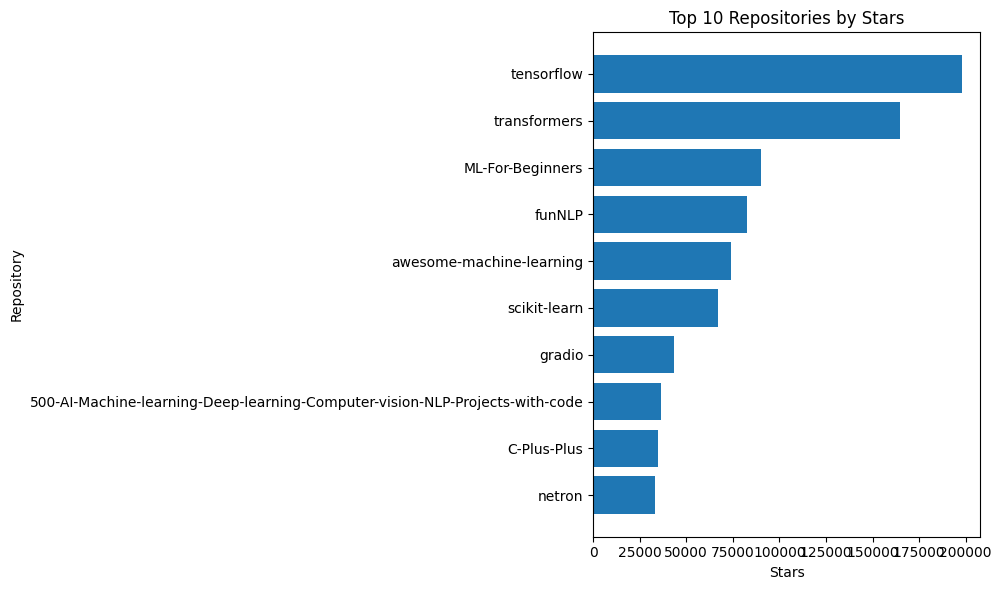

In [ ]:
import matplotlib.pyplot as plt
query = """
SELECT name, stars
FROM Repositories
ORDER BY stars DESC
LIMIT 10
"""
top_repositories = pd.read_sql_query(query, connection)
plt.figure(figsize=(10, 6))
plt.barh(top_repositories["name"][::-1], top_repositories["stars"][::-1])
plt.xlabel("Stars")
plt.ylabel("Repository")
plt.title("Top 10 Repositories by Stars")
plt.tight_layout()
plt.show()

In [ ]:
query = """
SELECT
    strftime('%Y', created_date) AS year,
    COUNT(*) AS repository_count
FROM Repositories
GROUP BY year
ORDER BY year
"""
creation_trend = pd.read_sql_query(query, connection)
print(creation_trend)

    year  repository_count
0   2009                 1
1   2010                 2
2   2011                 2
3   2013                 3
4   2014                 6
5   2015                 7
6   2016                14
7   2017                17
8   2018                18
9   2019                 7
10  2020                10
11  2021                 6
12  2022                 3
13  2023                 3
14  2024                 1


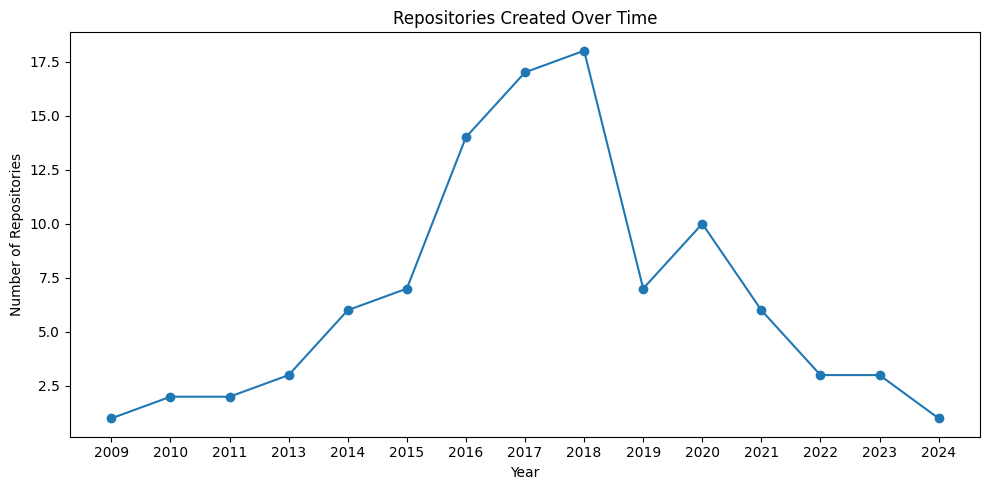

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(creation_trend["year"], creation_trend["repository_count"],marker="o")
plt.xlabel("Year")
plt.ylabel("Number of Repositories")
plt.title("Repositories Created Over Time")
plt.tight_layout()
plt.show()

 ***Step 8 – Interpretation of the Results***

From the analysis, it is evident that Python is the most widely used programming language within the repositories with 30 repositories using Python. There were some repositories that had no language defined, while Jupyter Notebook and C++ were other widely used languages.

The analysis reveals that there has been an increase in repository creation from one year to another and that the highest point was achieved in 2018 where there were 18 repositories created. After 2018, the number has generally gone down.

There is a very high positive correlation between stars and forks. It is clear that popular repositories with many stars also get many forks.

In conclusion, from the analysis of the results, it can be seen that machine learning repositories in the dataset are mostly related to Python programming language.

#Task 3:Ethics :-
**1. Why is it important to verify data collected from public APIs?**

It is important to check the accuracy of the data obtained from public APIs because the data might include missing or inaccurate entries. Since in this project, the repository data was collected from the GitHub API, the data set had to be checked to ensure that the analyzed information was accurate.

 **2. Why should data analysts document the source of their data?**
 The data analysts should document the data source because it would help trace the analysis to the origin of the data. In this project, the data was collected from the GitHub API. This fact makes it important to document the data source to make the project more transparent and understandable for other people.

 **3. How can missing or inaccurate data affect data analysis and decision-making?**

 Incorrect data or missing data can influence the analysis process as well as the outcome and can cause wrong decisions or wrong conclusions to be made. Missing information on programming languages in the GitHub data set, for instance, would have influenced the analysis of the most popular programming languages. Cleaning and validating the data would go a long way in minimizing such risks.




 **GitHub Repository**

--> GitHub Repository Link: https://github.com/omniatawfeek7/github-ml-data-analysis